# Diabetes Data Analysis
This project analyzes public health diabetes data and compares hospital stay length between male and female patients.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv",
    index_col=0
)

In [4]:
print(df.head())

              patient_nbr             race  gender      age weight  \
encounter_id                                                         
2278392           8222157        Caucasian  Female   [0-10)      ?   
149190           55629189        Caucasian  Female  [10-20)      ?   
64410            86047875  AfricanAmerican  Female  [20-30)      ?   
500364           82442376        Caucasian    Male  [30-40)      ?   
16680            42519267        Caucasian    Male  [40-50)      ?   

              admission_type_id  discharge_disposition_id  \
encounter_id                                                
2278392                       6                        25   
149190                        1                         1   
64410                         1                         1   
500364                        1                         1   
16680                         1                         1   

              admission_source_id  time_in_hospital payer_code  ...  \
encounter_

In [5]:
print(df.columns)

Index(['patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


## Data Cleaning

In this step, we remove rows with invalid or missing gender values and select only the relevant columns for analysis.

In [6]:
df = df[df["gender"].isin(["Male", "Female"])]

In [15]:
df_subset = df[["gender", "time_in_hospital"]].dropna()

In [16]:
df_subset.head()

,gender,time_in_hospital
encounter_id,,
2278392,Female,1
149190,Female,3
64410,Female,2
500364,Male,2
16680,Male,1


## Descriptive Statistics

We calculate summary statistics for hospital stay length by gender.

In [8]:
stats = df_subset.groupby("gender")["time_in_hospital"].describe()

In [9]:
print(stats)

          count      mean       std  min  25%  50%  75%   max
gender                                                       
Female  54708.0  4.478797  2.980388  1.0  2.0  4.0  6.0  14.0
Male    47055.0  4.299777  2.987703  1.0  2.0  3.0  6.0  14.0


## Visualization

The following bar chart shows the average time in hospital for male and female patients.

In [10]:
avg_time = df_subset.groupby("gender")["time_in_hospital"].mean()

In [11]:
print("\nAverage time in hospital:")


Average time in hospital:


In [12]:
print(avg_time)

gender
Female    4.478797
Male      4.299777
Name: time_in_hospital, dtype: float64


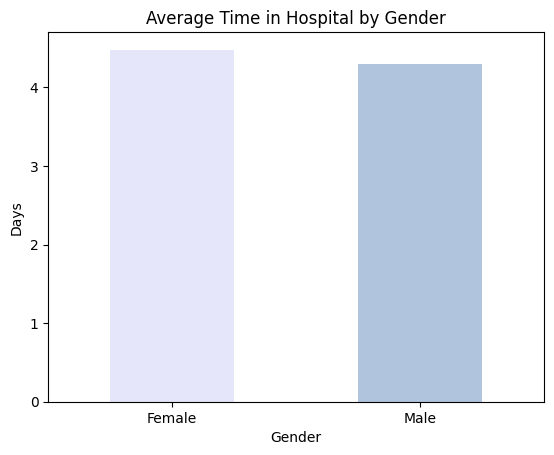

In [18]:
colors = ["lavender", "lightsteelblue"]
avg_time.plot(kind="bar", color=colors)
plt.title("Average Time in Hospital by Gender")
plt.ylabel("Days")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

## Conclusion

Male and female patients show a difference in average hospital stay length. This suggests that gender may influence hospitalization patterns in this dataset, although further analysis would be needed to confirm this relationship.